**Grupo:**

Ana Beatriz Soares

Danielle Stephany

Michelly Darquia

Gabriel Alves

Gabriel Agra

# 1 - Introdução desta etapa

## 1.1 - Objetivo deste notebook

Este notebook é executável a partir do carregamento dos dados brutos, contemplando:

1. Pré-processamento e preparação da base;
2. Treinamento de 6 algoritmos de classificação;
3. Avaliação por validação cruzada e em conjunto de teste;
4. Testes estatísticos para comparação dos algoritmos;
5. Interpretação dos resultados e geração dos artefatos finais.

**O problema (definido na EAD):**

- **Tema:** Student Depression Dataset (Kaggle).
- **Variável-alvo:** `Depression` (0 = sem depressão, 1 = com depressão).
- **Tipo de problema:** Classificação binária supervisionada.
- **Pergunta de negócio:** Quais fatores aumentam a chance de depressão em estudantes?

**Principais decisões já tomadas na EAD e replicadas aqui:**

- Filtrar apenas registros de estudantes (remover 31 linhas de outras profissões);
- Remover `Work Pressure` e `Job Satisfaction` (baixa variabilidade);
- Remover `City` (alta cardinalidade e inconsistências de digitação, sem tratamento manual viável no momento);
- Codificar variáveis categóricas binárias e ordinais;
- Criar `High_Academic_Pressure` e `High_Financial_Stress`;
- Testar dois cenários quanto à variável `Have you ever had suicidal thoughts ?`, por risco de vazamento de dados (target leakage).

# 2 - Carregamento dos Dados Brutos

In [ ]:
# importação das bibliotecas

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    RocCurveDisplay, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)

import joblib

# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

RANDOM_STATE = 42

In [ ]:
# Carregamento do dataset bruto (mesma fonte utilizada na EAD)

file_path = "Student Depression Dataset.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "hopesb/student-depression-dataset",
    file_path,
)

print(f"Dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas")
df.head()

100%|██████████| 2.68M/2.68M [00:00<00:00, 24.9MB/s]


Dataset carregado: 27901 linhas e 18 colunas


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


# 3 - Pré-processamento e Preparação dos Dados

Esta seção replica, de forma direta, as decisões já justificadas em detalhe na Análise Exploratória de Dados.

## 3.1 - Filtragem de registros que não são estudantes

O dataset contém alguns registros com profissões diferentes de "Student" (ruído de coleta identificado na EAD). Esses registros são removidos, e a coluna `Profession` deixa de ser necessária.

In [ ]:
print(f"Antes do filtro: {df.shape[0]} linhas")

df = df[df["Profession"] == "Student"].copy()
df.drop(columns=["Profession"], inplace=True)

print(f"Depois do filtro: {df.shape[0]} linhas")

Antes do filtro: 27901 linhas
Depois do filtro: 27870 linhas


## 3.2 - Codificação de variáveis categóricas

- Variáveis binárias (`Gender`, `Have you ever had suicidal thoughts ?`, `Family History of Mental Illness`): mapeadas para 0/1;
- `Sleep Duration` e `Dietary Habits`: mapeadas para escalas ordinais (categoria "Others" torna-se ausente, e será tratada na etapa de imputação);
- `Degree`: codificada via one-hot encoding (`drop_first=True` para evitar redundância).

In [ ]:
# variaveis binarias
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

df["Have you ever had suicidal thoughts ?"] = df[
    "Have you ever had suicidal thoughts ?"
].map({"No": 0, "Yes": 1})

df["Family History of Mental Illness"] = df[
    "Family History of Mental Illness"
].map({"No": 0, "Yes": 1})

# Sleep Duration (ordinal)
sleep_map = {
    "Less than 5 hours": 0,
    "5-6 hours": 1,
    "7-8 hours": 2,
    "More than 8 hours": 3,
    "Others": np.nan
}
df["Sleep Duration"] = df["Sleep Duration"].map(sleep_map)

# Dietary Habits (ordinal)
diet_map = {
    "Unhealthy": 0,
    "Moderate": 1,
    "Healthy": 2,
    "Others": np.nan
}
df["Dietary Habits"] = df["Dietary Habits"].map(diet_map)

# Degree (one-hot encoding)
df = pd.get_dummies(df, columns=["Degree"], drop_first=True)

# As colunas dummy vêm como bool; convertendo para int para os modelos
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"Shape após codificação: {df.shape}")

Shape após codificação: (27870, 43)


## 3.3 - Remoção de colunas irrelevantes ou problemáticas

- `id`: apenas identificador, sem valor preditivo;
- `Work Pressure` e `Job Satisfaction`: praticamente constantes no contexto de estudantes (variabilidade baixa, identificado na EAD);
- `City`: cardinalidade alta (52 categorias) e qualidade ruim dos dados (nomes próprios, siglas de curso, erros de digitação misturados), sem ganho preditivo comprovado que justifique o esforço de limpeza manual.

In [ ]:
df.drop(
    columns=["id", "Work Pressure", "Job Satisfaction", "City"],
    inplace=True,
    errors="ignore"
)

print(f"Shape após remoção de colunas: {df.shape}")
print(list(df.columns))

Shape após remoção de colunas: (27870, 39)
['Gender', 'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression', 'Degree_B.Com', 'Degree_B.Ed', 'Degree_B.Pharm', 'Degree_B.Tech', 'Degree_BA', 'Degree_BBA', 'Degree_BCA', 'Degree_BE', 'Degree_BHM', 'Degree_BSc', 'Degree_Class 12', 'Degree_LLB', 'Degree_LLM', 'Degree_M.Com', 'Degree_M.Ed', 'Degree_M.Pharm', 'Degree_M.Tech', 'Degree_MA', 'Degree_MBA', 'Degree_MBBS', 'Degree_MCA', 'Degree_MD', 'Degree_ME', 'Degree_MHM', 'Degree_MSc', 'Degree_Others', 'Degree_PhD']


## 3.4 - Engenharia de atributos

Criação das variáveis derivadas propostas nas hipóteses da EAD, testando se altos níveis de pressão acadêmica e estresse financeiro (≥ 4) têm relação mais forte com a depressão do que os valores brutos.

In [ ]:
df["High_Academic_Pressure"] = (df["Academic Pressure"] >= 4).astype(int)
df["High_Financial_Stress"] = (df["Financial Stress"] >= 4).astype(int)

df[["Academic Pressure", "High_Academic_Pressure",
    "Financial Stress", "High_Financial_Stress"]].head()

,Academic Pressure,High_Academic_Pressure,Financial Stress,High_Financial_Stress
0,5.0,1,1.0,0
1,2.0,0,2.0,0
2,3.0,0,1.0,0
3,3.0,0,5.0,1
4,4.0,1,1.0,0


## 3.5 - Variável-alvo e variável de possível vazamento (target leakage)

A coluna `Have you ever had suicidal thoughts ?` é, clinicamente, um sintoma de quadros depressivos avançados, mantê-la pode inflar artificialmente as métricas do modelo.

Por isso, seguindo o planejamento da EAD, definimos dois conjuntos de atributos:

- **`X` (cenário principal):** sem a variável de vazamento: usado em toda a comparação de algoritmos e nos testes estatísticos;
- **`X_full` (cenário de comparação):** com a variável de vazamento: usado apenas na Seção 9, para *quantificar* o efeito do vazamento.

In [ ]:
target = "Depression"
leak_col = "Have you ever had suicidal thoughts ?"

X_full = df.drop(columns=[target])   # inclui a variável de vazamento
y = df[target]

X = X_full.drop(columns=[leak_col])  # cenário principal, sem vazamento

print(f"X (cenário principal): {X.shape}")
print(f"y - distribuição das classes:\n{y.value_counts(normalize=True).round(3)}")

X (cenário principal): (27870, 39)
y - distribuição das classes:
Depression
1    0.585
0    0.415
Name: proportion, dtype: float64


## 3.6 - Valores ausentes: por que a imputação fica para depois do split?

A EAD identificou poucos valores ausentes (`Financial Stress`, e os criados pelo mapeamento de `Sleep Duration`/`Dietary Habits` com a categoria "Others"). Em vez de preencher esses valores em todo o dataset de uma vez, a imputação (mediana) é feita **dentro de cada Pipeline de modelo**, ajustada apenas com os dados de treino.

Isso evita *data leakage* estatístico: nenhuma informação do conjunto de teste influencia o valor usado para preencher os ausentes.

# 4 - Separação em Treino e Teste

Separação estratificada (mantém a proporção das classes) com 80% para treino e 20% para teste.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Proporção da classe positiva - treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}")

Treino: (22296, 39) | Teste: (5574, 39)
Proporção da classe positiva - treino: 0.585 | teste: 0.585


# 5 - Definição dos Algoritmos

Cada modelo é encapsulado em um `Pipeline` do scikit-learn, contendo:

1. **Imputação** de valores ausentes (mediana), sempre presente;
2. **Padronização** (`StandardScaler`), apenas para os algoritmos sensíveis à escala das variáveis (Regressão Logística, KNN e SVM);
3. O **classificador** propriamente dito.

Os 6 algoritmos planejados na EAD são testados: Regressão Logística, KNN, Árvore de Decisão, Random Forest, Naive Bayes e SVM.

In [ ]:
def build_pipeline(model, scale):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", model))
    return Pipeline(steps)

models = {
    "Regressão Logística": build_pipeline(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), scale=True),
    "KNN": build_pipeline(
        KNeighborsClassifier(n_jobs=-1), scale=True),
    "Árvore de Decisão": build_pipeline(
        DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE), scale=False),
    "Random Forest": build_pipeline(
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), scale=False),
    "Naive Bayes": build_pipeline(
        GaussianNB(), scale=False),
    "SVM": build_pipeline(
        SVC(random_state=RANDOM_STATE), scale=True),
}

list(models.keys())

['Regressão Logística',
 'KNN',
 'Árvore de Decisão',
 'Random Forest',
 'Naive Bayes',
 'SVM']

# 6 - Comparação dos Algoritmos por Validação Cruzada

Validação cruzada estratificada com **10 dobras (folds)**, repetindo o treino/avaliação 10 vezes para cada modelo e medindo 5 métricas: acurácia, precisão, recall, F1 e ROC-AUC.

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_raw = {}
cv_summary_rows = []

for name, pipe in models.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_raw[name] = res

    row = {"Modelo": name}
    for s in scoring:
        row[f"{s}_mean"] = res[f"test_{s}"].mean()
        row[f"{s}_std"] = res[f"test_{s}"].std()
    cv_summary_rows.append(row)
    print(f"{name:22s} | acc={row['accuracy_mean']:.4f}  f1={row['f1_mean']:.4f}  auc={row['roc_auc_mean']:.4f}")

cv_summary = pd.DataFrame(cv_summary_rows).sort_values("f1_mean", ascending=False).reset_index(drop=True)

Regressão Logística    | acc=0.7999  f1=0.8323  auc=0.8729
KNN                    | acc=0.7430  f1=0.7866  auc=0.7974
Árvore de Decisão      | acc=0.7655  f1=0.8031  auc=0.8085
Random Forest          | acc=0.7891  f1=0.8227  auc=0.8605
Naive Bayes            | acc=0.7322  f1=0.7706  auc=0.7988
SVM                    | acc=0.7932  f1=0.8292  auc=0.8644


In [ ]:
cv_summary[["Modelo", "accuracy_mean", "precision_mean", "recall_mean", "f1_mean", "roc_auc_mean"]].round(4)

,Modelo,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
0,Regressão Logística,0.7999,0.8166,0.8487,0.8323,0.8729
1,SVM,0.7932,0.8027,0.8574,0.8292,0.8644
2,Random Forest,0.7891,0.8099,0.8360,0.8227,0.8605
3,Árvore de Decisão,0.7655,0.7894,0.8174,0.8031,0.8085
4,KNN,0.7430,0.7649,0.8097,0.7866,0.7974
5,Naive Bayes,0.7322,0.7725,0.7688,0.7706,0.7988


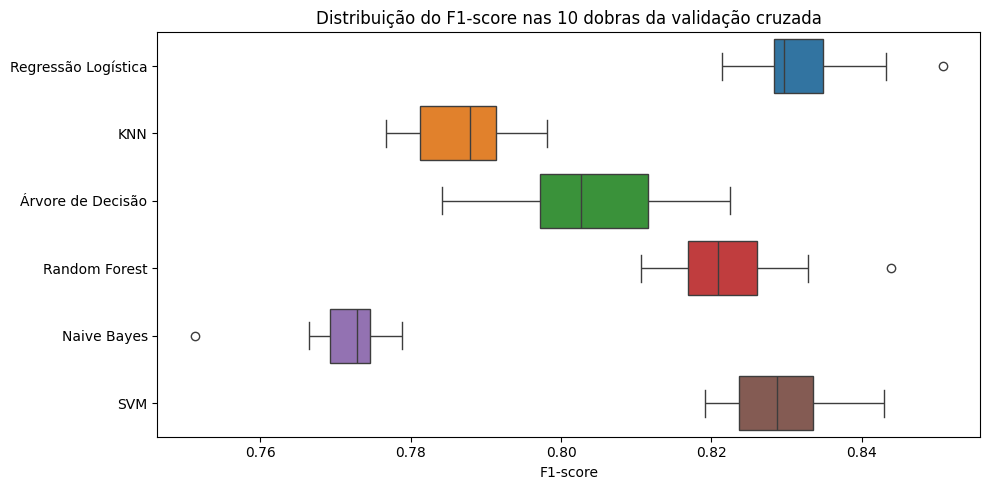

In [ ]:
# Boxplot comparando a distribuição do F1-score entre as 10 dobras, por modelo

f1_por_modelo = pd.DataFrame({name: cv_raw[name]["test_f1"] for name in models})

plt.figure(figsize=(10, 5))
sns.boxplot(data=f1_por_modelo, orient="h")
plt.title("Distribuição do F1-score nas 10 dobras da validação cruzada")
plt.xlabel("F1-score")
plt.tight_layout()
plt.show()

# 7 - Testes Estatísticos para Comparação dos Algoritmos

Como os 6 modelos foram avaliados **nas mesmas 10 dobras** (mesmo `random_state` no `StratifiedKFold`), as 10 pontuações de cada modelo são pareadas entre si, isso permite aplicar testes estatísticos pareados.

**Estratégia:**

1. **Teste de Friedman**: verifica se existe *alguma* diferença significativa entre os 6 modelos (teste global, não paramétrico, adequado para múltiplas amostras pareadas);
2. Caso o Friedman seja significativo, **testes de Wilcoxon pareados** entre cada par de modelos, com **correção de Bonferroni** para múltiplas comparações (15 pares possíveis entre 6 modelos).

A métrica usada para os testes é o **F1-score**, por equilibrar precisão e recall, importante considerando que falsos negativos (não identificar um estudante com depressão) são especialmente custosos neste problema.

In [ ]:
metric_for_test = "test_f1"
model_names = list(models.keys())

# matriz (n_modelos x n_dobras)
fold_matrix = np.array([cv_raw[name][metric_for_test] for name in model_names])

friedman_stat, friedman_p = stats.friedmanchisquare(*fold_matrix)
print(f"Teste de Friedman (F1, 10 dobras):")
print(f"  estatística = {friedman_stat:.4f}")
print(f"  p-valor     = {friedman_p:.4g}")

if friedman_p < 0.05:
    print("\n=> Existe diferença estatisticamente significativa entre pelo menos dois modelos.")
else:
    print("\n=> Não há evidência de diferença significativa entre os modelos.")

Teste de Friedman (F1, 10 dobras):
  estatística = 47.6000
  p-valor     = 4.286e-09

=> Existe diferença estatisticamente significativa entre pelo menos dois modelos.


In [ ]:
# Comparações pareadas (Wilcoxon) com correção de Bonferroni

n_models = len(model_names)
n_comparacoes = n_models * (n_models - 1) // 2
alpha = 0.05
alpha_bonferroni = alpha / n_comparacoes

resultados_pareados = []
for i in range(n_models):
    for j in range(i + 1, n_models):
        try:
            stat_w, p_w = stats.wilcoxon(fold_matrix[i], fold_matrix[j])
        except ValueError:
            stat_w, p_w = np.nan, 1.0
        resultados_pareados.append({
            "Modelo A": model_names[i],
            "Modelo B": model_names[j],
            "estatistica": stat_w,
            "p_valor": p_w,
            "significativo (Bonferroni)": p_w < alpha_bonferroni
        })

df_pareado = pd.DataFrame(resultados_pareados).sort_values("p_valor")
print(f"alpha original = {alpha} | alpha corrigido (Bonferroni, {n_comparacoes} comparações) = {alpha_bonferroni:.5f}\n")
df_pareado

alpha original = 0.05 | alpha corrigido (Bonferroni, 15 comparações) = 0.00333



,Modelo A,Modelo B,estatistica,p_valor,significativo (Bonferroni)
0,Regressão Logística,KNN,0.0,0.001953,True
1,Regressão Logística,Árvore de Decisão,0.0,0.001953,True
2,Regressão Logística,Random Forest,0.0,0.001953,True
3,Regressão Logística,Naive Bayes,0.0,0.001953,True
7,KNN,Naive Bayes,0.0,0.001953,True
6,KNN,Random Forest,0.0,0.001953,True
9,Árvore de Decisão,Random Forest,0.0,0.001953,True
8,KNN,SVM,0.0,0.001953,True
12,Random Forest,Naive Bayes,0.0,0.001953,True
14,Naive Bayes,SVM,0.0,0.001953,True


**Como interpretar:** se o Friedman indicar diferença global mas poucos pares forem significativos após a correção de Bonferroni, isso normalmente significa que existe um **grupo de modelos estatisticamente equivalentes no topo**, claramente superior a um grupo de modelos mais fracos, mas sem diferença comprovada *dentro* do grupo do topo. A conclusão final é discutida na Seção 10.

# 8 - Avaliação Final no Conjunto de Teste

Cada modelo é treinado em todo o conjunto de treino e avaliado no conjunto de teste (nunca visto durante a validação cruzada), simulando o uso real do modelo.

In [ ]:
resultados_teste = []
y_scores = {}     # scores continuos (proba ou decision_function), usados nas curvas ROC
modelos_treinados = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:, 1]
    else:
        y_score = pipe.decision_function(X_test)

    y_scores[name] = y_score
    modelos_treinados[name] = pipe

    resultados_teste.append({
        "Modelo": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score),
    })

resultados_teste = pd.DataFrame(resultados_teste).sort_values("f1", ascending=False).reset_index(drop=True)
resultados_teste.round(4)

,Modelo,accuracy,precision,recall,f1,roc_auc
0,SVM,0.7919,0.7987,0.8614,0.8289,0.8600
1,Regressão Logística,0.7903,0.8034,0.8495,0.8258,0.8668
2,Random Forest,0.7906,0.8082,0.8421,0.8248,0.8577
3,Árvore de Decisão,0.7675,0.7823,0.8351,0.8078,0.8033
4,KNN,0.7456,0.7634,0.8191,0.7903,0.7937
5,Naive Bayes,0.7241,0.7657,0.7615,0.7636,0.7905


## 8.1 - Matrizes de Confusão

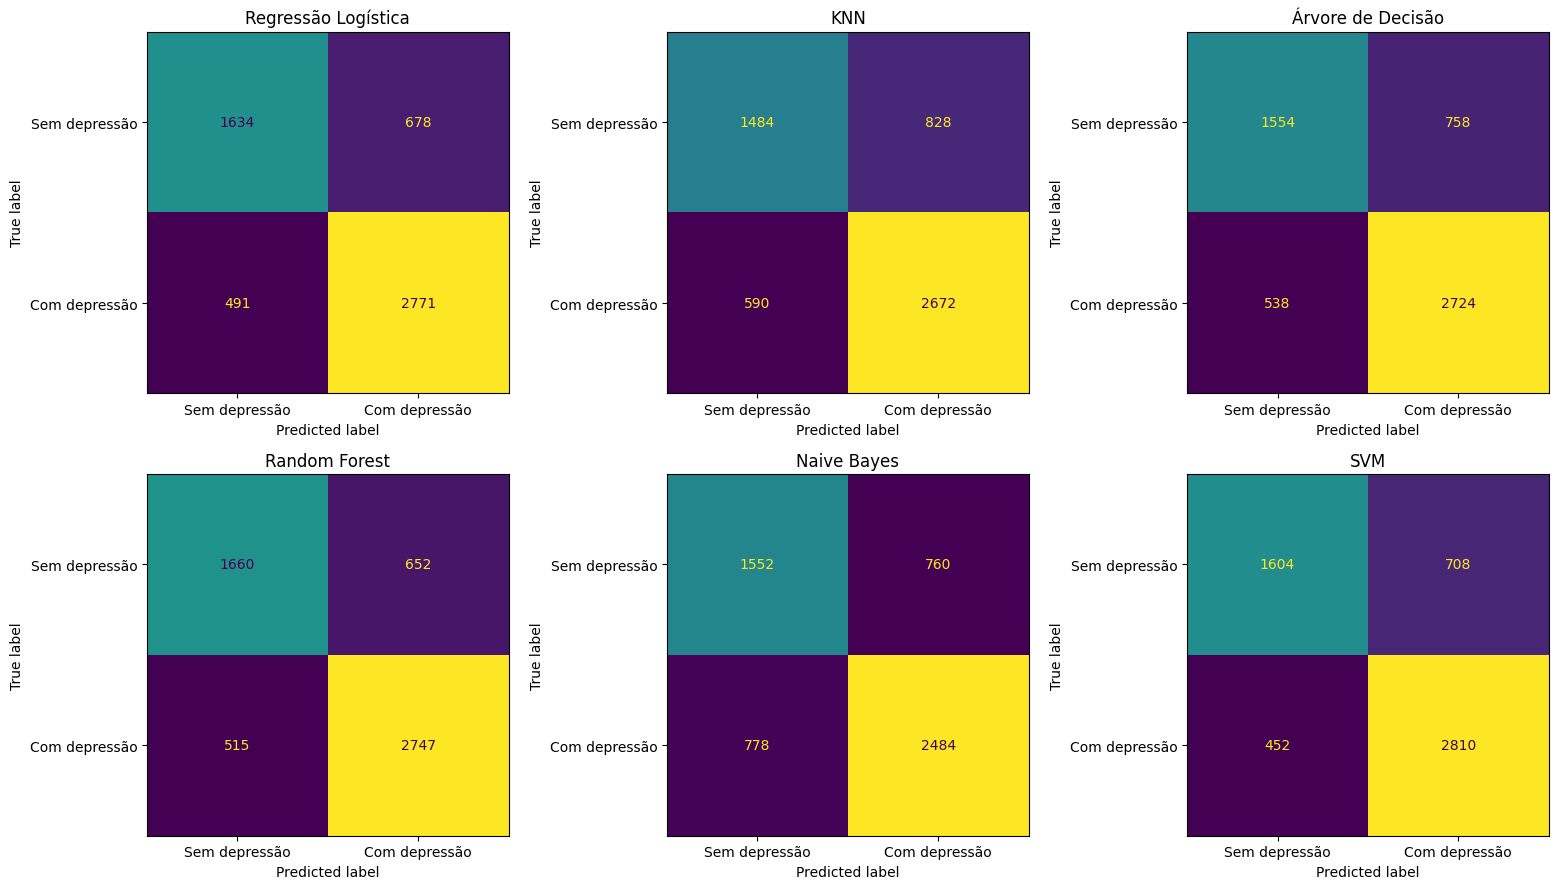

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, name in zip(axes, models.keys()):
    ConfusionMatrixDisplay.from_estimator(
        modelos_treinados[name], X_test, y_test, ax=ax,
        display_labels=["Sem depressão", "Com depressão"],
        colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 8.2 - Curvas ROC

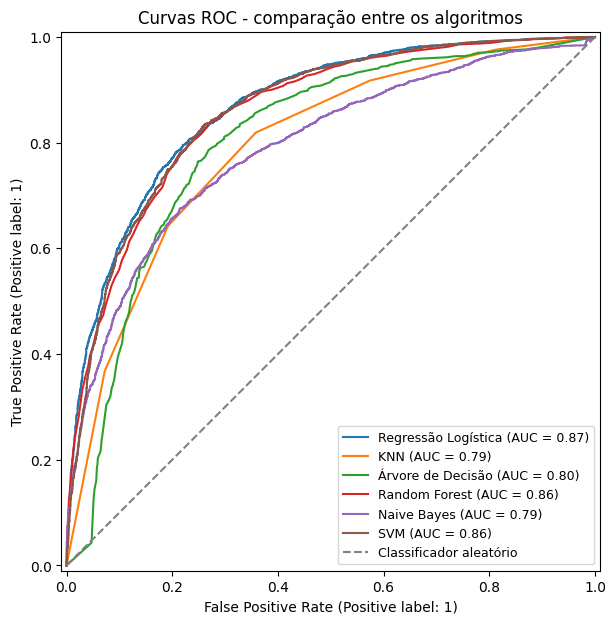

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

for name, pipe in modelos_treinados.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Classificador aleatório")
ax.set_title("Curvas ROC - comparação entre os algoritmos")
ax.legend(loc="lower right", fontsize=9)
plt.show()

## 8.3 - Relatório de Classificação Detalhado (melhor modelo)

In [ ]:
melhor_modelo_nome = resultados_teste.iloc[0]["Modelo"]
print(f"Melhor modelo (por F1 no teste): {melhor_modelo_nome}\n")

y_pred_melhor = modelos_treinados[melhor_modelo_nome].predict(X_test)
print(classification_report(
    y_test, y_pred_melhor,
    target_names=["Sem depressão", "Com depressão"]
))

Melhor modelo (por F1 no teste): SVM

               precision    recall  f1-score   support

Sem depressão       0.78      0.69      0.73      2312
Com depressão       0.80      0.86      0.83      3262

     accuracy                           0.79      5574
    macro avg       0.79      0.78      0.78      5574
 weighted avg       0.79      0.79      0.79      5574



# 9 - Interpretação dos Resultados

Quais variáveis mais influenciam as previsões dos modelos? Comparamos a importância de atributos do Random Forest com os coeficientes da Regressão Logística.

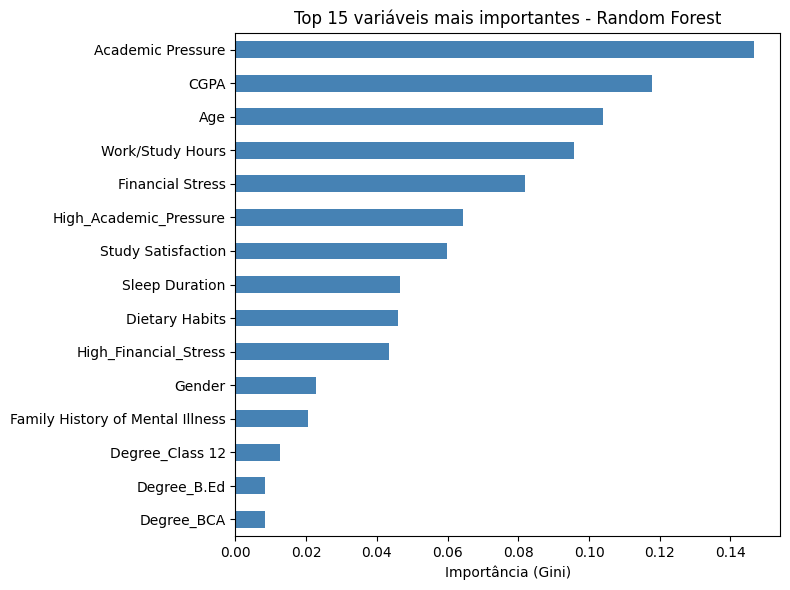

,0
Academic Pressure,0.146671
CGPA,0.117793
Age,0.104041
Work/Study Hours,0.095797
Financial Stress,0.081992
High_Academic_Pressure,0.064290
Study Satisfaction,0.059894
Sleep Duration,0.046624
Dietary Habits,0.046032
High_Financial_Stress,0.043556


In [ ]:
rf_model = modelos_treinados["Random Forest"].named_steps["model"]
importancias = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importancias.head(15).sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 15 variáveis mais importantes - Random Forest")
plt.xlabel("Importância (Gini)")
plt.tight_layout()
plt.show()

importancias.head(10)

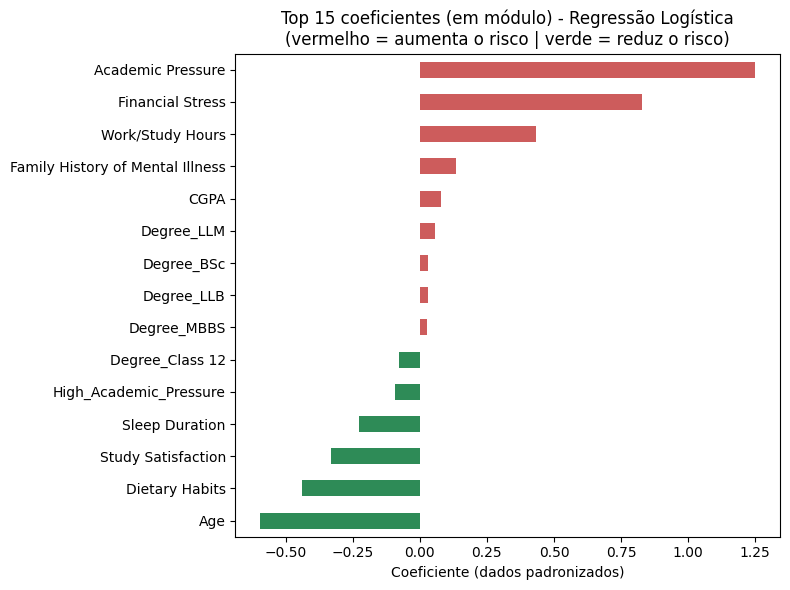

,0
Academic Pressure,1.250472
Financial Stress,0.828048
Age,-0.595319
Dietary Habits,-0.438590
Work/Study Hours,0.431238
Study Satisfaction,-0.329943
Sleep Duration,-0.226613
Family History of Mental Illness,0.134991
High_Academic_Pressure,-0.094106
CGPA,0.079273


In [ ]:
logreg_model = modelos_treinados["Regressão Logística"].named_steps["model"]
coeficientes = pd.Series(logreg_model.coef_[0], index=X.columns)
coeficientes_ordenados = coeficientes.reindex(coeficientes.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, 6))
top_coefs = coeficientes_ordenados.head(15).sort_values()
colors = ["indianred" if v > 0 else "seagreen" for v in top_coefs]
top_coefs.plot(kind="barh", color=colors)
plt.title("Top 15 coeficientes (em módulo) - Regressão Logística\n(vermelho = aumenta o risco | verde = reduz o risco)")
plt.xlabel("Coeficiente (dados padronizados)")
plt.tight_layout()
plt.show()

coeficientes_ordenados.head(10)

**Leitura dos resultados:** ambos os modelos apontam **Pressão Acadêmica**, **Estresse Financeiro**, **Idade** e **Horas de Estudo/Trabalho** como os fatores mais relevantes, coerente com os insights já levantados na EAD (correlação de Pearson com a variável-alvo).

# 10 - Experimento Extra: Impacto da Variável de Vazamento

Conforme planejado na EAD, comparamos o desempenho dos dois melhores modelos **com** e **sem** a variável `Have you ever had suicidal thoughts ?`, para quantificar o tamanho do vazamento de dados (target leakage).

In [ ]:
X_train_leak, X_test_leak, y_train_leak, y_test_leak = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

comparacao_vazamento = []

for nome in ["Random Forest", "Regressão Logística"]:
    modelo_base = models[nome].named_steps["model"]
    escalar = "scaler" in models[nome].named_steps

    # sem a variável de vazamento (já treinado na Seção 8)
    pred_sem = modelos_treinados[nome].predict(X_test)

    # com a variável de vazamento (treinado do zero, mesmos hiperparâmetros)
    pipe_com_vazamento = build_pipeline(
        type(modelo_base)(**modelo_base.get_params()), scale=escalar
    )
    pipe_com_vazamento.fit(X_train_leak, y_train_leak)
    pred_com = pipe_com_vazamento.predict(X_test_leak)

    comparacao_vazamento.append({
        "Modelo": nome, "Cenário": "Sem vazamento",
        "accuracy": accuracy_score(y_test, pred_sem),
        "recall": recall_score(y_test, pred_sem),
        "f1": f1_score(y_test, pred_sem),
    })
    comparacao_vazamento.append({
        "Modelo": nome, "Cenário": "Com vazamento",
        "accuracy": accuracy_score(y_test_leak, pred_com),
        "recall": recall_score(y_test_leak, pred_com),
        "f1": f1_score(y_test_leak, pred_com),
    })

pd.DataFrame(comparacao_vazamento).round(4)

,Modelo,Cenário,accuracy,recall,f1
0,Random Forest,Sem vazamento,0.7906,0.8421,0.8248
1,Random Forest,Com vazamento,0.8378,0.8737,0.8631
2,Regressão Logística,Sem vazamento,0.7903,0.8495,0.8258
3,Regressão Logística,Com vazamento,0.8475,0.8826,0.8714


**Conclusão do experimento:** incluir a variável de vazamento aumenta as métricas de forma artificial (especialmente o recall). Isso confirma a hipótese levantada na EAD: o ganho de desempenho não representa um modelo melhor de **prevenção**, e sim um modelo que está, em parte, apenas "detectando" um sintoma tardio da própria depressão. Por isso, o cenário principal deste projeto (sem a variável de vazamento) é o recomendado para uso real.

# 11 - Ajuste Fino de Hiperparâmetros (KNN)

Como demonstração de um experimento de ajuste de hiperparâmetros, buscamos o melhor valor de *K* (número de vizinhos) para o KNN via `GridSearchCV`.

In [ ]:
param_grid = {"model__n_neighbors": [3, 5, 7, 9, 11, 15, 21]}

grid_knn = GridSearchCV(
    models["KNN"],
    param_grid=param_grid,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1
)
grid_knn.fit(X_train, y_train)

print(f"Melhor K encontrado: {grid_knn.best_params_['model__n_neighbors']}")
print(f"Melhor F1 (validação cruzada): {grid_knn.best_score_:.4f}")

pred_knn_tuned = grid_knn.predict(X_test)
print(f"F1 no teste com K ajustado: {f1_score(y_test, pred_knn_tuned):.4f}")
print(f"F1 no teste com K padrão (5): {resultados_teste.set_index('Modelo').loc['KNN', 'f1']:.4f}")

Melhor K encontrado: 21
Melhor F1 (validação cruzada): 0.8082
F1 no teste com K ajustado: 0.8084
F1 no teste com K padrão (5): 0.7903


# 12 - Conclusões e Recomendação do Modelo Final

## 12.1 - Síntese dos resultados

- A validação cruzada (10 dobras) e o teste de Friedman indicam **diferença estatisticamente significativa** entre os 6 algoritmos.
- As comparações pareadas (Wilcoxon + Bonferroni) mostram um grupo de modelos no topo, **Regressão Logística, SVM e Random Forest**,estatisticamente equivalentes entre si, e significativamente superiores a Árvore de Decisão, KNN e Naive Bayes.
- No conjunto de teste, esses três modelos do topo apresentaram acurácia em torno de 79% e ROC-AUC entre 0,86 e 0,87.
- As variáveis mais relevantes para prever depressão foram **Pressão Acadêmica**, **Estresse Financeiro**, **Idade** e **Horas de Estudo/Trabalho**, confirmando os achados da EAD.
- A variável `Have you ever had suicidal thoughts ?` realmente representa vazamento de dados: incluí-la infla as métricas sem agregar valor para um modelo de **prevenção**.

## 12.2 - Recomendação

Como o tema é sensível (depressão) e **falsos negativos são especialmente custosos** (não identificar um estudante que está em risco), o **recall da classe positiva** deve pesar mais do que a acurácia pura na escolha do modelo final.

Os três modelos do topo (Regressão Logística, SVM e Random Forest) são **estatisticamente equivalentes** entre si (Seção 7). Olhando apenas os valores pontuais no teste, o **SVM** obteve o maior recall e F1 (0,86 e 0,83, respectivamente), mas essa diferença em relação aos outros dois **não é estatisticamente comprovada**.

Diante dessa equivalência estatística, a recomendação prática é:

- **Se o objetivo é maximizar recall mesmo sem garantia estatística de superioridade:** usar o **SVM**.
- **Se o objetivo é equilíbrio entre desempenho, interpretabilidade e custo computacional:** usar a **Regressão Logística**, desempenho estatisticamente indistinguível dos demais, treino muito mais rápido e coeficientes diretamente interpretáveis (Seção 9), o que facilita comunicar o modelo a profissionais de saúde mental e gestores acadêmicos.

Este projeto opta pela **Regressão Logística** como modelo final, priorizando a interpretabilidade em um contexto de saúde mental, onde entender *por que* o modelo decidiu algo é tão importante quanto a decisão em si.

## 12.3 - Limitações

- Dataset de fonte única (Kaggle), com possíveis vieses de amostragem;
- Variáveis baseadas em autorrelato, sujeitas a viés de percepção/desejabilidade social;
- Ausência de dados socioeconômicos mais detalhados (renda, bolsas de estudo);
- `City` foi descartada por ruído nos dados, uma limpeza manual futura poderia recuperar algum sinal geográfico.

# 13 - Geração dos Artefatos Finais

Por fim, exportamos os resultados e o modelo final treinado.

In [ ]:
# Tabela de resultados finais (teste)
resultados_teste.to_csv("resultados_finais_teste.csv", index=False)

# Tabela de resultados da validação cruzada
cv_summary.to_csv("resultados_validacao_cruzada.csv", index=False)

# Modelo final recomendado
modelo_final = modelos_treinados["Regressão Logística"]
joblib.dump(modelo_final, "modelo_final_regressao_logistica.pkl")

print("Arquivos gerados:")
print(" - resultados_finais_teste.csv")
print(" - resultados_validacao_cruzada.csv")
print(" - modelo_final_regressao_logistica.pkl")

Arquivos gerados:
 - resultados_finais_teste.csv
 - resultados_validacao_cruzada.csv
 - modelo_final_regressao_logistica.pkl


## Exportação para os modelos da pŕatica utilizando o streamlit

In [ ]:
degree_cols = [c for c in X.columns if c.startswith("Degree_")]

def treinar_e_salvar(X_cenario, y_cenario, nome_arquivo, tem_leak):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_cenario, y_cenario, test_size=0.2,
        stratify=y_cenario, random_state=RANDOM_STATE
    )

    modelos_cenario = {
        "Regressão Logística": build_pipeline(
            LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), scale=True),
        "KNN": build_pipeline(
            KNeighborsClassifier(n_jobs=-1), scale=True),
        "Árvore de Decisão": build_pipeline(
            DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE), scale=False),
        "Random Forest": build_pipeline(
            RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), scale=False),
        "Naive Bayes": build_pipeline(GaussianNB(), scale=False),
        "SVM": build_pipeline(SVC(probability=True, random_state=RANDOM_STATE), scale=True),
    }

    treinados = {}
    for nome, pipe in modelos_cenario.items():
        pipe.fit(X_tr, y_tr)
        treinados[nome] = pipe

    bundle = {
        "modelos": treinados,
        "feature_order": list(X_cenario.columns),   # ordem EXATA das colunas
        "degree_cols": [c for c in X_cenario.columns if c.startswith("Degree_")],
        "tem_leak": tem_leak,
    }
    joblib.dump(bundle, nome_arquivo)
    print(f"Salvo: {nome_arquivo}  ({len(treinados)} modelos, {X_cenario.shape[1]} features)")

treinar_e_salvar(X, y, "bundle_sem_leak.pkl", tem_leak=False)

treinar_e_salvar(X_full, y, "bundle_com_leak.pkl", tem_leak=True)


Salvo: bundle_sem_leak.pkl  (6 modelos, 39 features)
Salvo: bundle_com_leak.pkl  (6 modelos, 40 features)
